# Industrial Computer Vision

In [1]:
from matplotlib import pyplot as plt
from numpy import array
from PIL import Image

from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.models import Sequential, save_model
from tensorflow.keras.layers import Conv2D # Zum Schärfen unseres Bildes
from tensorflow.keras.layers import MaxPool2D # Zum "Einkochen unserer Bilder"
from tensorflow.keras.layers import Dense, Input, Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import RandomBrightness, RandomFlip, RandomZoom

from tensorflow.random import set_seed

set_seed(123)

## Look into images

Hier haben wir uns mit unserem Datenmaterial auseinandergesetzt. Wir haben die `imread`-Methode benutzt, um ein Bild zu laden und `imshow` um dieses Bild anschließend darzustellen. Hier haben wir die drei Kanäle des Bildes (Red, Green, und Blue) einzeln dargestellt. Jede dieser Farbschichten ist eine Matrix mit Werten, welche die Sättigung des Bildes in der jeweiligen Farbe beschreiben.

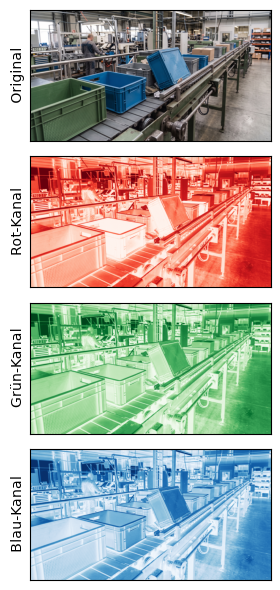

In [2]:
fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(4,6))

ax[0].imshow(plt.imread("../data/jammed/image_02.jpeg"))
ax[0].set_ylabel("Original")
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].imshow(plt.imread("../data/jammed/image_02.jpeg")[:,:,0], cmap="Reds")
ax[1].set_ylabel("Rot-Kanal")
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[2].imshow(plt.imread("../data/jammed/image_02.jpeg")[:,:,1], cmap="Greens")
ax[2].set_ylabel("Grün-Kanal")
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[3].imshow(plt.imread("../data/jammed/image_02.jpeg")[:,:,2], cmap="Blues")
ax[3].set_ylabel("Blau-Kanal")
ax[3].set_xticks([])
ax[3].set_yticks([])

plt.tight_layout()
plt.show()

## Load Data

Hier haben wir die Daten geladen. Wir nutzen dazu deine `tensorflow`-Funktion, die einen großteil der Arbeit für uns erledigt. Hierunter fällt vor allem das Batching der Daten. Dabei werden mehrere Datensätze (`batch_size`) in einen Tensor zusammengefasst. Später beim Training, schicken wir dann immer einen Batch ins Rennen, berechnen basierend auf diesem Batch den Fehler unseres Netzes und stellen das Netz über diesen Fehler ein. Diesen Vorgang wiederholen wir mit allen verbleibenden Batches - erst dann ist die Trainings-Epoche abgeschlossen.

Dieses Vorgehen ist praktisch, weil dadurch das Anpassen der Gewichte einfacher wird. Gleichzeitig müssen wir die Gewichte in einer Epoche mehrfach angreifen, wodurch das Training langsamer wird. Das festlegen der Batch-Größe ist demnach eine Gratwanderung zwischen smoothen Gradienten und Trainingsgeschwindigkeit.

In [3]:
training_data = image_dataset_from_directory(
    "../data",
    image_size=(224, 224),
    batch_size=3,
    seed=123
)

Found 12 files belonging to 3 classes.


Mit Hilfe des `class_names` Attributs können wir schnell überprüfen, welche Klassen der Loader im Bild-Ordner gefunden hat. Die Reihennfolge der Namen entspricht auch der Zuordnung dieser Klassen zu den Output-Neuronen unseres späteren Netzes. Hier würde z. B. das erste Output-Neuron die Klasse `empty` repräsentieren, das zweite die Klasse `free` usw..

In [4]:
training_data.class_names

['empty', 'free', 'jammed']

 Hier haben wir noch die Struktur unserer Tensoren überprüft. Wir iterieren dazu über die ersten `10` Batches unseres Loaders. Innerhalb der Schleife zeigen wir dann die Labels der enthaltenen Bilder und den Bild-Tensor selbst an. Hier sehen wir dass jeder Batch `3` RGB-Bilder (`3` Kanäle) mit je `224`x`224` Pixeln enthält.

In [5]:
for images, labels in training_data.take(10):
    print(labels)
    print(images.shape)
    print(images[0])

tf.Tensor([0 1 1], shape=(3,), dtype=int32)
(3, 224, 224, 3)
tf.Tensor(
[[[118.36735  125.0102   124.79591 ]
  [100.02042  108.02042  110.02042 ]
  [ 91.57145  102.50512  104.50512 ]
  ...
  [194.01486  198.01486  201.01486 ]
  [213.90807  217.90807  218.90807 ]
  [ 89.8893    98.31752  101.10341 ]]

 [[114.14796  119.14796  115.14796 ]
  [134.98979  140.98979  138.56122 ]
  [120.09694  125.05102  121.06632 ]
  ...
  [192.73877  196.73877  199.73877 ]
  [214.42357  218.42357  219.42357 ]
  [ 87.63555   97.63555   99.63555 ]]

 [[133.77553  139.77553  137.77553 ]
  [140.31122  146.31122  144.31122 ]
  [126.81125  132.81125  128.81125 ]
  ...
  [193.84256  198.84256  201.84256 ]
  [208.71439  209.71439  211.71439 ]
  [102.509186 109.509186 115.509186]]

 ...

 [[ 62.147896  70.147896  81.147896]
  [117.17795  130.17795  139.17795 ]
  [114.33181  124.33181  133.3318  ]
  ...
  [174.80556  178.80556  177.80556 ]
  [169.47519  169.47519  169.47519 ]
  [161.31085  163.31085  162.31085 ]]

 [

## Create Model

Hier haben wir selbst unser CNN geschrieben. Wir haben dazu einen **Feature-Extractor** Entwickelt, der unsere Bilder schärft und einkocht. Dieser wird dann von einem **Image-Klassifier** ergänzt, der die eigentliche Klassifizierung übernimmt. Oberhalb vom Feature-Extractor haben wir noch einen Block mit Randomisierungsschichten eingefügt. Dieser erhöht beim Training die Herausforderung für unser Netz, indem Bilder z. B. zufällig gedreht werden. Da wir einen sehr kleinen Datensatz benutzen, haben wir diesen Block auskommentiert, weil er mehr Probleme gemacht, als gelöst hat.

In [6]:
model = Sequential()
model.add(Input(shape=(224, 224, 3)))

# Randomisierungsschicht
#model.add(RandomFlip())
#model.add(RandomZoom(0.2))
#model.add(RandomBrightness(-0.2))

# Feature-Extractor
model.add(Conv2D(24, kernel_size=3, activation="relu"))
model.add(MaxPool2D(pool_size=2))
model.add(Conv2D(12, kernel_size=3, activation="relu"))
model.add(MaxPool2D(pool_size=2))
model.add(Flatten())

# Image-Klassifier
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.25))
model.add(Dense(3, activation="softmax"))

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 24)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 12)   │         2,604 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 34992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,239,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,243,023 (8.56 MB)

 Trainable params: 2,243,023 (8.56 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

Hier haben wir unser Modell mit Hilfe vom Optimizer `Adam()` trainiert. Als Loss verwenden wir die `sparse_categorical_crossentropy`. Die Berechnet wie sortenrein unsere Klassifizierung ist und erlaubt es uns, unseren `y`-Vektor in einem sparsen Format zu übergeben. Hier stehen die werte an der jeweiligen Stelle des Vektors für die entsprechende Klasse (z. B. `[0, 1, 2, 1, 0]`).

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy"
)

In [9]:
log = model.fit(training_data, epochs=15, verbose=1)

Epoch 1/15


/Users/michaelkohlegger/Documents/GitHub/industrial_computing_dibse_26/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 467.5917 
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 373.2696
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 81.5820
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9.7847 
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0844
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7628    
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3257
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0956
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1480
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0334
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0161    
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0105
Epoch 13/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0593
Epoch 14/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0018    
Epoch 15/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0037


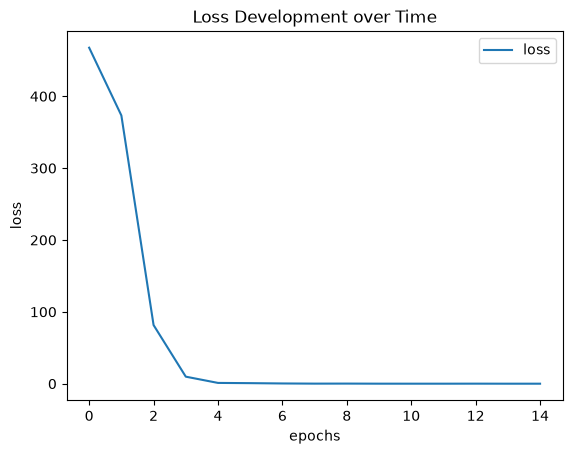

In [10]:

plt.title("Loss Development over Time")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.plot(log.history["loss"], label="loss")
plt.legend(loc=0)
plt.show()

## Model ausprobieren

Hier haben wir ein Bild geladen und dann durch unser trainiertes Netz geschickt. Zuvor aber, haben wir das Bild in ein `numpy.array` umgewandelt, in seiner Größe angepasst (so dass es zu unserem Netz passt) und den Bild-Tensor um eine Dimension erweitert. Das war nötig, weil unser Netz immer mehrere Bilder auf einmal verarbeiten muss (so haben wir es ihm beigebracht), auch wenn wir eigentlich nur ein Bild durch das Netz schicken wollen. 

In [11]:
img = plt.imread("../data/free/image_01.jpeg")

img_pil = Image.fromarray(img)
img_arr = array(img_pil.resize((224, 224)))
img_arr = img_arr.reshape(1, 224, 224, 3)

model.predict(img_arr).argmax()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


np.int64(1)

## Model serialisieren

Hier haben wir das Netz serialisiert, um es später wiederverwenden zu können.

In [12]:
model.save("../api/model_cnn.keras")